   Author: Henry CH Yeung, University of Virginia

In [1]:
import tensorflow as tf
import numpy as np

get_ipython().run_line_magic('env', 'SM_FRAMEWORK=tf.keras')
import segmentation_models as sm
sm.set_framework('tf.keras')

from PIL import Image
import rasterio
import imgaug as ia
from imgaug import augmenters as iaa
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import imageio
import os
import time
import rasterio.warp             # Reproject raster samples
from functools import reduce
from tensorflow.keras.models import load_model

from core.UNet import UNet
from core.losses import tversky, focal_tversky
from core.optimizers import adaDelta, adagrad, adam, nadam
from core.frame_info import FrameInfo
from core.dataset_generator import DataGenerator
from core.split_frames import split_dataset
from core.visualize import display_images
from segmentation_models.losses import JaccardLoss, DiceLoss, CategoricalCELoss
from segmentation_models.metrics import IOUScore, FScore, Precision, Recall


import json
from sklearn.model_selection import train_test_split

get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt  # plotting tools
import matplotlib.patches as patches
from matplotlib.patches import Polygon

import warnings                  # ignore annoying warnings
warnings.filterwarnings("ignore")
import logging
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

get_ipython().run_line_magic('reload_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print('Tensorflow version:', tf.__version__)
print('Num GPU available:', len(tf.config.list_physical_devices('GPU')))

env: SM_FRAMEWORK=tf.keras
Segmentation Models: using `tf.keras` framework.
Tensorflow version: 2.4.1
Num GPU available: 1


In [2]:
# Required configurations (including the input and output paths) are stored in a separate file (such as config/UNetTraining.py)
# Please provide required info in the file before continuing with this notebook. 
 
from config import FineTuning
# In case you are using a different folder name such as configLargeCluster, then you should import from the respective folder 
# Eg. from configLargeCluster import UNetTraining
config = FineTuning.Configuration()

In [ ]:
# Read all images/frames into memory
frames_train = []
frames_val = []

def build_frame_list(baseDir):
    frames = []
    
    all_files = os.listdir(baseDir)
    all_files_ndvi = [fn for fn in all_files if fn.startswith(config.ndvi_fn) and fn.endswith(config.image_type)]
#     all_files_ndvi = [fn for fn in all_files if fn.startswith(config.ndvi_fn) and fn.endswith(config.image_type)]
    
    for i, fn in enumerate(all_files_ndvi):
        ndvi_img = rasterio.open(os.path.join(baseDir, fn))
        r_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.r_fn)))
        g_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.g_fn)))
        b_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.b_fn)))
        n_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.n_fn)))
#         print(fn)
        read_ndvi_img = ndvi_img.read()
        if not np.isnan(read_ndvi_img).all() and np.any(read_ndvi_img): # filter dataframe with NaN or all zeros
            read_r_img = r_img.read()
            read_g_img = g_img.read()
            read_b_img = b_img.read()
            read_n_img = n_img.read()
            comb_img = np.concatenate((read_ndvi_img, read_r_img, read_g_img, read_b_img, read_n_img), axis=0)
            comb_img = np.transpose(comb_img, axes=(1,2,0)) #Channel at the end
            annotation_im = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.annotation_fn)))
            annotation = annotation_im.read(1)
    #         if np.any(annotation): # remove all empty label dataframes
            weight_im = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.weight_fn)))
            weight = weight_im.read(1)
            f = FrameInfo(comb_img, annotation, weight)
            frames.append(f)
    return frames

frames_train = build_frame_list(config.base_dir_train)
frames_val = build_frame_list(config.base_dir_val)
# frames_random = frames_train + frames_val
print(f'Built {len(frames_train)} of training frames and {len(frames_val)} of validation frames')

In [31]:
# Load a pretrained model
OPTIMIZER = adam
trained_model_path = os.path.join(config.trained_model_dir, config.trained_model_name+config.model_file_type)
model = load_model(trained_model_path, custom_objects={'ftversky': focal_tversky}, compile=False)
# model.compile(optimizer=OPTIMIZER, loss=tversky)
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 256, 256, 4)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 256, 256, 3)       15        
_________________________________________________________________
model (Functional)           (None, None, None, 1)     37468673  
Total params: 37,468,688
Trainable params: 37,293,968
Non-trainable params: 174,720
_________________________________________________________________


KerasTensor(type_spec=TensorSpec(shape=(None, None, None, 1), dtype=tf.float32, name=None), name='sigmoid/Sigmoid:0', description="created by layer 'sigmoid'")


[]

[]

[]

[]

...

[]

[]

[]

[]

[]

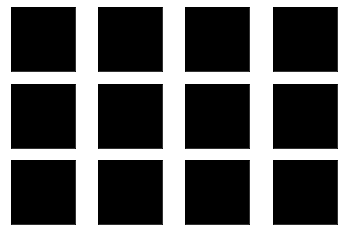

In [30]:

# Create a new model that outputs the output of the convolutional layer
conv_layer_name = 'model'  # Adjust this based on the actual name of your convolutional layer
conv_output = model.get_layer(conv_layer_name).output

print(conv_output)
# visualization_model = Model(inputs=model.input, outputs=conv_output)

# Loop through all layers and visualize filters for convolutional layers
for layer in model.layers:
    if 'conv' not in layer.name:
        continue
    
    # Get filters from the convolutional layer
    filters, biases = layer.get_weights()
    
    # Normalize filter values to 0-1 for visualization
    f_min, f_max = filters.min(), filters.max()
    filters = (filters - f_min) / (f_max - f_min)
    
    # Plot first few filters
    n_filters, ix = 3, 1
    for i in range(min(n_filters, filters.shape[-1])):
        # Get the filter
        f = filters[:, :, :, i]
        
        # Plot each channel separately
        for j in range(f.shape[-1]):
            # Specify subplot and turn off axis
            ax = plt.subplot(n_filters, f.shape[-1], ix)
            ax.set_xticks([])
            ax.set_yticks([])
            
            # Plot filter channel in grayscale
            plt.imshow(f[:, :, j], cmap='gray')
            ix += 1

# Show the figure
plt.show()

In [9]:
#File path for final report 
timestr = time.strftime("%Y%m%d-%H%M")
chf = input_image_channel + input_label_channel
chs = reduce(lambda a,b: a+str(b), chf, '')

evaluation_report_path = model_path = './eval_efficientnet/'
if not os.path.exists(evaluation_report_path):
    os.makedirs(evaluation_report_path)
evaluation_report_filename = os.path.join(evaluation_report_path,'evaluation_per_pixel{}_{}_thres{}.csv'.format(timestr,chs,thres))


In [10]:
# Read all images/frames into memory
frames = []

all_files = os.listdir(base_dir)
all_files_ndvi = [fn for fn in all_files if fn.startswith(ndvi_fn) and fn.endswith(image_type)]
len(all_files_ndvi)
#dtype = {'F': np.float32, 'L': np.uint8}[pil_img.mode]
for i, fn in enumerate(all_files_ndvi):
    ndvi_img = rasterio.open(os.path.join(base_dir, fn))
    r_img = rasterio.open(os.path.join(base_dir, fn.replace(ndvi_fn,r_fn)))
    g_img = rasterio.open(os.path.join(base_dir, fn.replace(ndvi_fn,g_fn)))
    b_img = rasterio.open(os.path.join(base_dir, fn.replace(ndvi_fn,b_fn)))
    n_img = rasterio.open(os.path.join(base_dir, fn.replace(ndvi_fn,n_fn)))
    
    read_ndvi_img = ndvi_img.read()
    if not np.isnan(read_ndvi_img).all():
        read_r_img = r_img.read()
        read_g_img = g_img.read()
        read_b_img = b_img.read()
        read_n_img = n_img.read()
        comb_img = np.concatenate((read_ndvi_img, read_r_img, read_g_img, read_b_img, read_n_img), axis=0)
        comb_img = np.transpose(comb_img, axes=(1,2,0)) #Channel at the end
        annotation_im = rasterio.open(os.path.join(base_dir, fn.replace(ndvi_fn,annotation_fn)))
        annotation = annotation_im.read(1).astype('int32')
        weight_im = rasterio.open(os.path.join(base_dir, fn.replace(ndvi_fn,weight_fn)))
        weight = weight_im.read(1).astype('int32')
        f = FrameInfo(comb_img, annotation, weight)
        frames.append(f)
    
len(frames)

11

11

In [11]:
# For testing on all frames. All sequential frames are kept in memory and this may create memory related errors in some cases. 
testing_frames  = list(range(len(frames)))
annotation_channels = input_label_channel + input_weight_channel
test_generator = DataGenerator(input_image_channel, patch_size, testing_frames, frames, annotation_channels)

# Sequential generate all patches from the all frames
test_patches = test_generator.all_sequential_patches(step_size, BACKBONE=preprocess)
print('Total patches to evaluate the model on: ' + str(len(test_patches[0])))

Total patches to evaluate the model on: 35


1.0


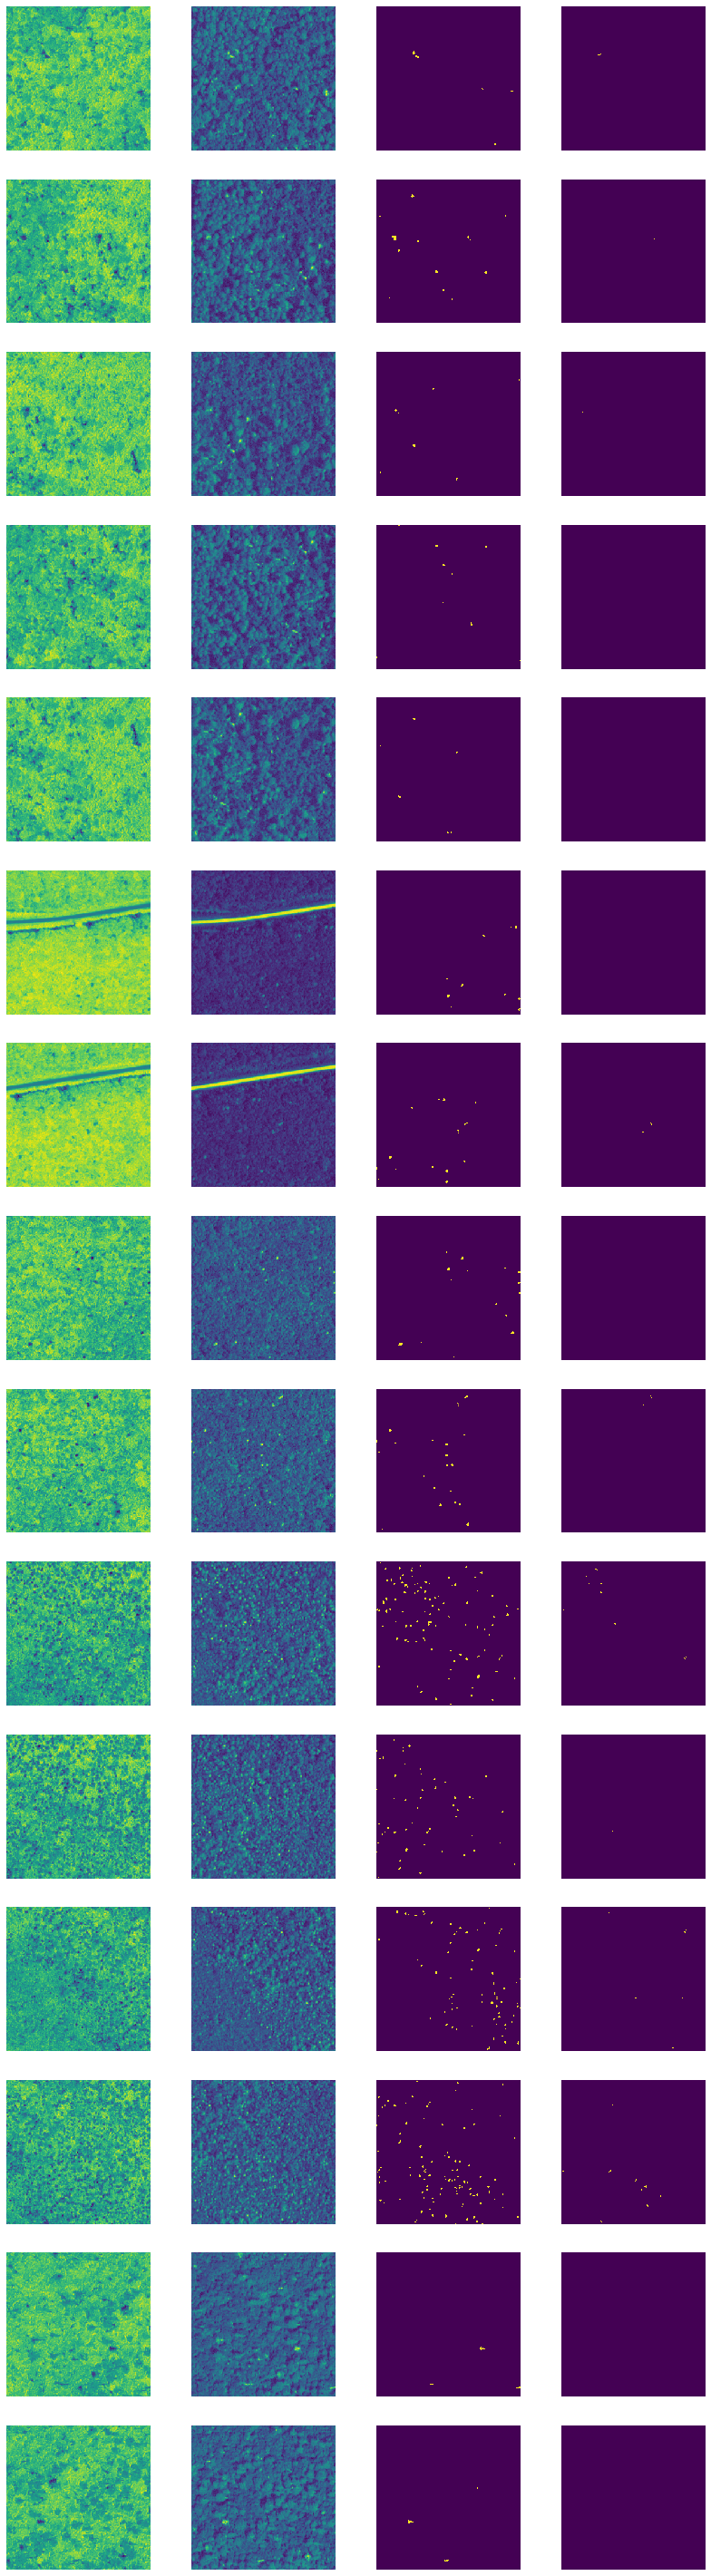

In [12]:
#Display the some of the test images
numberOfImagesToDisplay = 15

train_images, real_label = test_patches[0][:numberOfImagesToDisplay], test_patches[1][:numberOfImagesToDisplay]
display_images(np.concatenate((train_images[...,[0,3]],real_label), axis = -1))
print(train_images.max())

In [13]:
#Evaluate model
def evaluate_model(model_path, evaluation_report_filename):
    print(model_path, evaluation_report_filename)
    model = load_model(model_path, custom_objects={'tversky': LOSS, 'DiceLoss': DiceLoss(class_indexes=0), 'JaccardLoss': JaccardLoss(class_indexes=0), 'F1-Score': FScore(class_indexes=0, threshold=thres), 'IOU-Score': IOUScore(class_indexes=0, threshold=thres), 'Precision': Precision(class_indexes=0, threshold=thres), 'Recall': Recall(class_indexes=0, threshold=thres)}, compile=False)
    model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[DiceLoss(class_indexes=0), JaccardLoss(class_indexes=0), FScore(class_indexes=0, threshold=thres), IOUScore(class_indexes=0, threshold=thres), Precision(class_indexes=0, threshold=thres), Recall(class_indexes=0, threshold=thres)])
    print('Evaluating model now!')
    ev = model.evaluate(x=test_patches[0], y=test_patches[1], verbose=1, use_multiprocessing=True)
    report  = dict(zip(model.metrics_names, ev))
    report['model_path'] =  model_path
    report['threshold'] = thres
    report['test_frame_dir']= base_dir
    report['total_patch_count']= len(test_patches[0])
    return report

report = evaluate_model(modelToEvaluate, evaluation_report_filename)
report

# tdf = pd.DataFrame(report, index=[0])    
# col_beginning = ['model_path', 'threshold', 'test_frame_dir', 'total_patch_count']
# col_rest = [x for x in tdf.columns.tolist() if x not in col_beginning]
# cols = col_beginning + col_rest
# tdf = tdf[cols]
# tdf.to_csv(evaluation_report_filename)

./saved_models/UNet/trees_efficientnetb3pt_20230505-0014_Adam_weightmap_ftversky5575_012345_256.h5 ./eval_efficientnet/evaluation_per_pixel20230505-0920_012345_thres0.5.csv
Evaluating model now!
35/35 [==============================] - 2s 71ms/sample - loss: 0.4069 - dice_loss: 0.2769 - jaccard_loss: 0.4337 - f1-score: 0.7252 - iou_score: 0.5689 - precision: 0.6961 - recall: 0.7580


{'loss': 0.4068957737513951,
 'dice_loss': 0.27691457,
 'jaccard_loss': 0.43369547,
 'f1-score': 0.725158,
 'iou_score': 0.5688577,
 'precision': 0.69610435,
 'recall': 0.758041,
 'model_path': './saved_models/UNet/trees_efficientnetb3pt_20230505-0014_Adam_weightmap_ftversky5575_012345_256.h5',
 'threshold': 0.5,
 'test_frame_dir': '../output_eval',
 'total_patch_count': 35}

In [1]:
# # Show the model predictions!
model = load_model(modelToEvaluate, custom_objects={'tversky': LOSS, 'DiceLoss': DiceLoss(class_indexes=0), 'JaccardLoss': JaccardLoss(class_indexes=0), 'F1-Score': FScore(class_indexes=0, threshold=thres), 'IOU-Score': IOUScore(class_indexes=0, threshold=thres), 'Precision': Precision(class_indexes=0, threshold=thres), 'Recall': Recall(class_indexes=0, threshold=thres)}, compile=False)# # model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[DiceLoss(class_indexes=0), JaccardLoss(class_indexes=0), FScore(class_indexes=0), IOUScore(class_indexes=0), Precision(class_indexes=0, threshold=0.5), Recall(class_indexes=0, threshold=0.5)])

predictions = []
for tp in test_patches[0]:
    tpx = np.expand_dims(tp, axis=0)
    modelpredtictions = model.predict(tpx, batch_size=BATCH_SIZE)
    predictions.append(np.squeeze(modelpredtictions, axis = 0))

display_images(np.concatenate((test_patches[0][...,[0,1]], test_patches[1][...,[0]], predictions), axis = -1))
# display_images(np.concatenate((test_patches[1][...,[0]], predictions), axis = -1))

NameError: name 'load_model' is not defined

In [1]:
# Transform Contours from image to world coordinates  
def transform_contours_to_xy(contours, transform):
    tp = []
    for cnt in contours:
        pl = cnt[:, 0, :]
        cols, rows = zip(*pl)
        x,y = rasterio.transform.xy(transform, rows, cols)
        tl = [list(i) for i in zip(x, y)]
        tp.append(tl)
    return (tp)

def mask_to_polygons(mask, transform, th = 0.5):
    # first, find contours with cv2: it's much faster than shapely and returns hierarchy
    mask[mask < th] = 0
    mask[mask >= th] = 1
    mask = ((mask) * 255).astype(np.uint8)
    contours, hierarchy = cv2.findContours(mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    
    #Convert contours from image coordinate to xy coordinate (world coordinates)
    contours = transform_contours_to_xy(contours, transform)

    if not contours: #TODO: Raise an error maybe
        print('Warning: No contours/polygons detected!!')
        return [Polygon()]#[Polygon()]
    
    # now messy stuff to associate parent and child contours
    cnt_children = defaultdict(list)
    child_contours = set()
    assert hierarchy.shape[0] == 1
    # http://docs.opencv.org/3.1.0/d9/d8b/tutorial_py_contours_hierarchy.html
    for idx, (_, _, _, parent_idx) in enumerate(hierarchy[0]):
        if parent_idx != -1:
            child_contours.add(idx)
            cnt_children[parent_idx].append(contours[idx])
    # create actual polygons filtering by area/hole (removes artifacts)
    all_polygons = []
    for idx, cnt in enumerate(contours):
        if idx not in child_contours: #and cv2.contourArea(cnt) >= min_area: #Do we need to check for min_area??
            try:
                poly = Polygon(
                    shell=cnt,
                    holes=[c for c in cnt_children.get(idx, [])])
                           #if cv2.contourArea(c) >= min_area]) #Do we need to check for min_area??
                all_polygons.append(poly)
            except Exception as e: 
#                 print(e)
                pass
#     print(len(all_polygons))
    return(all_polygons)

In [25]:
import pyproj    
import shapely
import shapely.ops as ops

def transform_to_meter_coordinate_system(geom):
    # TODO: Remove the hard coded values
    project = pyproj.Transformer.from_proj(
        pyproj.Proj(init='epsg:26918'), # source coordinate system
        pyproj.Proj(init='epsg:26918')) # destination coordinate system
    gt = ops.transform(project.transform, geom)  # apply projection
    return gt

def ha_area(ha_polygons):
    ts = 0
    ha_polygons_meter = [transform_to_meter_coordinate_system(p) for p in ha_polygons]
    for p in ha_polygons_meter:
        ts += p.area
    return ts

def ha_area_from_mask(mask, th = 0.5):
    mask[mask < th] = 0
    mask[mask >= th] = 1
#     totalMaskArea = 256*256/4
    canopyArea = mask.sum()/4 # Divide by 4, since we use a resolution of 50cm/pixel
    return canopyArea

# TODO: Remove the need for the a tiff file for transformation
with rasterio.open('../rawImage/ndvi_m_3507501_sw_18_060_20200516.tif') as raster_image:
#     print(raster_image.meta)
    transform = raster_image.meta['transform']
print(transform)

ha_prediction_polygons = []
ha_label_polygons = []
    
ha_prediction_canopy_area = []
ha_label_canopy_area = []

for em, pred in enumerate(predictions):
    ap = mask_to_polygons(pred, transform )
    ha_prediction_polygons.append(ap)
    ha_prediction_canopy_area.append(ha_area_from_mask(pred))

for lb in test_patches[1][...,[0]]:
    ap = mask_to_polygons(lb, transform)
    ha_label_polygons.append(ap)
    ha_label_canopy_area.append(ha_area_from_mask(lb))

| 0.60, 0.00, 409429.20|
| 0.00,-0.60, 3977833.20|
| 0.00, 0.00, 1.00|


In [26]:
ha_prediction_polygons_count = [len(hp) for hp in ha_prediction_polygons]
ha_label_polygons_count = [len(hp) for hp in ha_label_polygons]

#Alternate method to calcualte canopy area as a sum of area of trees
# print('To calculate the area we convert the polygons to a coordinate system where unit is meters. This process is time consuming.')
# ha_prediction_canopy_area = list(map(ha_area, ha_prediction_polygons))
# ha_label_canopy_area = list(map(ha_area, ha_label_polygons))

In [27]:
from scipy.stats import pearsonr
print(len(ha_prediction_polygons_count))
ha_count_correlation = pearsonr(ha_prediction_polygons_count, ha_label_polygons_count)
ha_area_correlation = pearsonr(ha_prediction_canopy_area, ha_label_canopy_area)

print('Count correlation:' + str(ha_count_correlation))
print('Area correlation:' + str(ha_area_correlation))

11
Count correlation:(0.7641523800591626, 0.006177056623354892)
Area correlation:(0.7469879027588043, 0.00824790060175781)


In [28]:
# # Generate the final report

# report['count_correlation'] =  ha_count_correlation[0]
# report['count_correlation_tvalue'] =  ha_count_correlation[1]
# report['area_correlation'] = ha_area_correlation[0]
# report['area_correlation_tvalue'] =  ha_area_correlation[1]

# # print(report)

# tdf = pd.DataFrame(report, index=[0])    
# # print(tdf.columns)
# col_beginning = ['model_path','test_frame_dir', 'total_patch_count']
# col_rest = [x for x in tdf.columns.tolist() if x not in col_beginning]
# cols = col_beginning + col_rest
# tdf = tdf[cols]
# tdf.to_csv(evaluation_report_filename)

Text(1, 150, 'y = 0.68x15.57')

(-18.226428262004795,
 210.82110829238763,
 -18.226428262004795,
 210.82110829238763)

Text(0.5, 0, 'Labelled Dead Tree Count / ha')

Text(0, 0.5, 'Predicted Dead Tree Count / ha')

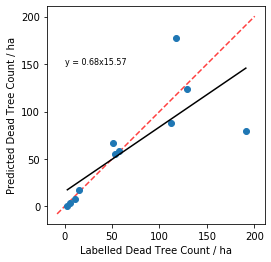

In [29]:
x, y = ha_label_polygons_count,ha_prediction_polygons_count
plt.scatter(x,y)

#find line of best fit
a, b = np.polyfit(x, y, 1)
plt.plot(np.unique(x), a*np.unique(x)+b, 'k-')
plt.text(1, 150, 'y =' + ' {:.2f}'.format(a) + 'x' + '{:.2f}'.format(b), size=8)

# Plot 1:1 line
lims = [np.min([plt.xlim(), plt.ylim()]), np.max([plt.xlim(), plt.ylim()])]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
plt.axis('square')
plt.xlabel('Labelled Dead Tree Count / ha')
plt.ylabel('Predicted Dead Tree Count / ha')
plt.show()

Text(1, 450, 'y = 0.98x7.19')

(-54.386694260485655,
 664.3866942604857,
 -54.386694260485655,
 664.3866942604857)

Text(0.5, 0, 'Labelled Dead Tree Canopy Area / ha')

Text(0, 0.5, 'Predicted Dead Tree Canopy Area / ha')

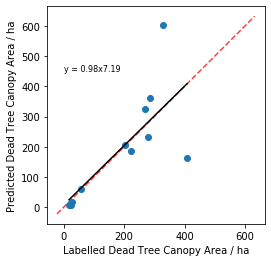

In [30]:
x, y = ha_label_canopy_area, ha_prediction_canopy_area
plt.scatter(x,y)

#find line of best fit
a, b = np.polyfit(x, y, 1)
plt.plot(np.unique(x), a*np.unique(x)+b, 'k-')
plt.text(1, 450, 'y =' + ' {:.2f}'.format(a) + 'x' + '{:.2f}'.format(b), size=8)

# Plot 1:1 line
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
plt.axis('square')
plt.xlabel('Labelled Dead Tree Canopy Area / ha')
plt.ylabel('Predicted Dead Tree Canopy Area / ha')
plt.show()